# Análise Exploratória dos Dados

> **Autor**: Miguel Vieira Machado Pim  
> **Contexto**: Desafio do processo seletivo de estágio IndustriALL

Notebooks anteriores a este:

1. [`01_pre_processing`](01_pre_processing.ipynb)
2. [`02_data_visualization`](02_data_visualization.ipynb)

**IDEIAS**:

- Primeiro, devo selecionar um conjunto de variáveis para analisar. Isso porque a quantidade de sensores é muito grande.
- Após esse processo de analisar quais variáveis são mais importantes, iremos analisar tendência e sazonalidade.

## Bibliotecas

In [22]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.patches import Patch
from scipy.stats import wilcoxon, rankdata

## Funções

In [5]:
def preprocess_data(data_path: Path) -> pd.DataFrame:
    """
    Essa função coleta todos os 53 arquivos csv e converte eles em um único dataframe final.

    Args:
        data_path (Path): Caminho para a pasta que contém os arquivos csv.

    Returns:
        pd.DataFrame: Dataframe final contendo todas as features e a coluna target.
    """
    # Coletando todos os arquivos
    feature_dfs = []

    for file in data_path.glob("*.csv"):
        if "target" in file.name:
            target_df = pd.read_csv(file)
        else:
            feature_dfs.append(pd.read_csv(file))
    
    # Renomeando as colunas
    for i, df in enumerate(feature_dfs):
        columns = ["timestamp", f"sensor_{i}"]
        
        df.columns = columns
    
    columns = ["timestamp", "target"]
    target_df.columns = columns
    
    # Tratando tipos dos datasets
    for df in feature_dfs:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    target_df["target"] = target_df["target"].map({
        "NORMAL": 0,
        "ANORMAL": 1
    }).astype(int)
    target_df["timestamp"] = pd.to_datetime(target_df["timestamp"])
    
    # Construindo dataset final
    df_final = (
        pd.concat(
            [target_df.set_index("timestamp")] +
            [df.set_index("timestamp") for df in feature_dfs],
            axis=1,
            join="outer" # Para mantermos timestamps que não estão em todas as tabelas
        )
        .sort_index()
    )
    
    return df_final

In [6]:
def plotar_nulos_no_tempo(df, variaveis, figsize=(18, 2.5)):
    dados = df.sort_index()
    target = dados["target"]

    inicios_falha = dados.index[
        target.eq(1) & target.shift(fill_value=0).eq(0)
    ]

    finais_falha = dados.index[
        target.eq(1) & target.shift(-1, fill_value=0).eq(0)
    ]

    fig, axes = plt.subplots(
        len(variaveis),
        1,
        figsize=(figsize[0], figsize[1] * len(variaveis)),
        sharex=True
    )

    axes = [axes] if len(variaveis) == 1 else axes

    for i, (ax, variavel) in enumerate(zip(axes, variaveis)):
        nulos = dados[variavel].isna()

        ax.fill_between(
            dados.index,
            0,
            1,
            where=nulos,
            step="post",
            alpha=0.9
        )

        for inicio in inicios_falha:
            ax.axvline(
                inicio,
                color="red",
                linestyle="--",
                linewidth=1,
                label="Início da falha" if i == 0 and inicio == inicios_falha[0] else None
            )

        for fim in finais_falha:
            ax.axvline(
                fim,
                color="black",
                linestyle=":",
                linewidth=1,
                label="Fim da falha" if i == 0 and fim == finais_falha[0] else None
            )

        ax.set_yticks([0, 1])
        ax.set_yticklabels(["PRESENTE", "NULO"])
        ax.set_ylim(-0.05, 1.05)

        ax.set_title(
            f"{variavel} — {nulos.sum():,} nulos ({nulos.mean():.2%})"
        )

    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("Timestamp")

    fig.suptitle("Valores nulos e falhas ao longo do tempo", y=1)
    plt.tight_layout()
    plt.show()

In [7]:
def plotar_boxplots_todas_falhas(
    df,
    minutos=60,
    sensores_por_linha=5
):
    sensor_cols = [
        f"sensor_{i}"
        for i in range(52)
        if f"sensor_{i}" in df.columns
    ]

    target = df["target"]

    inicios = df.index[
        target.eq(1) & target.shift(fill_value=0).eq(0)
    ]

    finais = df.index[
        target.eq(1) & target.shift(-1, fill_value=0).eq(0)
    ]

    falhas = list(zip(inicios, finais))

    janelas = []

    for inicio, fim in falhas:
        pre = df.loc[
            (df.index >= inicio - pd.Timedelta(minutes=minutos)) &
            (df.index < inicio),
            sensor_cols
        ]

        pos = df.loc[
            (df.index > fim) &
            (df.index <= fim + pd.Timedelta(minutes=minutos)),
            sensor_cols
        ]

        janelas.append((pre, pos))

    n_colunas = sensores_por_linha
    n_linhas = math.ceil(len(sensor_cols) / n_colunas)

    fig, axes = plt.subplots(
        n_linhas,
        n_colunas,
        figsize=(5 * n_colunas, 4 * n_linhas),
        sharex=False,
        sharey=False
    )

    axes = np.atleast_1d(axes).ravel()

    posicoes = []
    rotulos = []

    for i in range(len(falhas)):
        base = i * 3 + 1

        posicoes.extend([base, base + 1])
        rotulos.extend([
            f"F{i + 1}\nPré",
            f"F{i + 1}\nPós"
        ])

    for ax, sensor in zip(axes, sensor_cols):
        for i, (pre, pos) in enumerate(janelas):
            pos_pre = i * 3 + 1
            pos_pos = pos_pre + 1

            antes = pre[sensor].dropna().values
            depois = pos[sensor].dropna().values

            if len(antes):
                ax.boxplot(
                    [antes],
                    positions=[pos_pre],
                    widths=0.75,
                    showfliers=False,
                    patch_artist=True,
                    boxprops={"facecolor": "tab:blue", "alpha": 0.7},
                    medianprops={"color": "black"}
                )

            if len(depois):
                ax.boxplot(
                    [depois],
                    positions=[pos_pos],
                    widths=0.75,
                    showfliers=False,
                    patch_artist=True,
                    boxprops={"facecolor": "tab:orange", "alpha": 0.7},
                    medianprops={"color": "black"}
                )

        ax.set_xticks(posicoes)
        ax.set_xticklabels(rotulos, fontsize=8)
        ax.set_title(sensor)
        ax.set_ylabel("Valor")
        ax.grid(axis="y", alpha=0.2)

    for ax in axes[len(sensor_cols):]:
        ax.axis("off")

    fig.legend(
        handles=[
            Patch(facecolor="tab:blue", alpha=0.7, label="Pré-falha"),
            Patch(facecolor="tab:orange", alpha=0.7, label="Pós-falha")
        ],
        loc="upper center",
        ncol=2
    )

    fig.suptitle(
        f"{minutos} minutos antes e depois de todas as falhas",
        y=0.995
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Carregando os dados

In [8]:
data_path = Path("../data")

industry_df = preprocess_data(data_path)

In [9]:
eda_df = industry_df.copy()
eda_df

,target,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,156.908398,310.022461,101.547023,71.130001,9.271792,1513.429451,197.014054,33.066858,553.695424,...,426.651658,140.957957,223.192894,69.511954,4.548754,1842.687291,721.402437,120.531554,2121.942413,1463.647280
2018-04-01 00:01:00,0,160.845276,306.084796,71.846296,98.697513,7.989979,1264.045436,549.491578,165.013373,864.166251,...,375.316113,148.975866,1225.833795,92.131989,7.887998,1810.309041,656.074488,94.319273,1914.209147,1437.274642
2018-04-01 00:02:00,0,157.841402,353.863854,59.174616,39.329786,8.771413,1357.757041,710.303108,68.023284,815.342106,...,444.809188,94.262093,42.455318,86.164997,4.975919,1508.671751,1060.796664,40.182165,1805.064984,1565.113515
2018-04-01 00:03:00,0,156.106507,301.563110,0.674927,126.751846,9.234399,1416.592337,451.379204,140.740890,773.406188,...,414.052496,154.828040,525.719895,32.473642,6.304142,1483.740243,719.418238,64.405477,1295.933558,1966.270851
2018-04-01 00:04:00,0,163.462727,298.957820,71.785623,41.526627,9.101509,1468.721792,1014.853751,113.162924,574.974685,...,431.548430,137.733814,950.064772,37.866648,1.671733,1600.106478,995.108386,31.432756,1765.669551,1396.339609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,0,62.866123,432.326663,77.001917,65.363544,19.892409,1232.957436,1109.264083,118.109623,656.615973,...,NaN,125.823406,573.821696,64.660949,6.066461,1536.191947,1636.798313,26.951498,1830.736428,1374.907651
2018-08-31 23:56:00,0,62.559359,402.294815,32.268873,103.837882,19.871804,1137.196994,834.517562,76.645996,895.475564,...,NaN,181.885424,446.990809,59.595192,4.057784,1573.813766,1333.129871,57.522306,1691.045537,1588.607137
2018-08-31 23:57:00,0,56.077536,269.339456,87.497962,129.919948,19.719878,1022.073096,427.420013,100.267292,700.493429,...,NaN,135.716614,1058.093047,84.392649,6.751912,1552.763450,953.370947,20.965076,1972.697864,1574.224086


## Analisando datas que não estão no dataset

In [10]:
timestamps = pd.DatetimeIndex(eda_df.index).sort_values().unique()

datas_esperadas = pd.date_range(
    start=timestamps.min(),
    end=timestamps.max(),
    freq="1min"
)

datas_ausentes = datas_esperadas.difference(timestamps)

print(f"Período: {timestamps.min()} até {timestamps.max()}")
print(f"Datas esperadas: {len(datas_esperadas):,}")
print(f"Datas existentes: {len(timestamps):,}")
print(f"Datas ausentes: {len(datas_ausentes):,}")
print(f"Cobertura: {len(timestamps) / len(datas_esperadas):.2%}")

Período: 2018-04-01 00:00:00 até 2018-08-31 23:59:00
Datas esperadas: 220,320
Datas existentes: 220,320
Datas ausentes: 0
Cobertura: 100.00%


Todas as datas possíveis para a frequência de 1 minuto existem no *dataset*. Portanto, não devemos nos preocupar em tratá-las.

## Analisando valores nulos no dataset

In [11]:
nulos = pd.DataFrame({
    "quantidade_nulos": eda_df.isna().sum(),
    "percentual_nulos": eda_df.isna().mean().mul(100).round(2)
}).sort_values("quantidade_nulos", ascending=False)

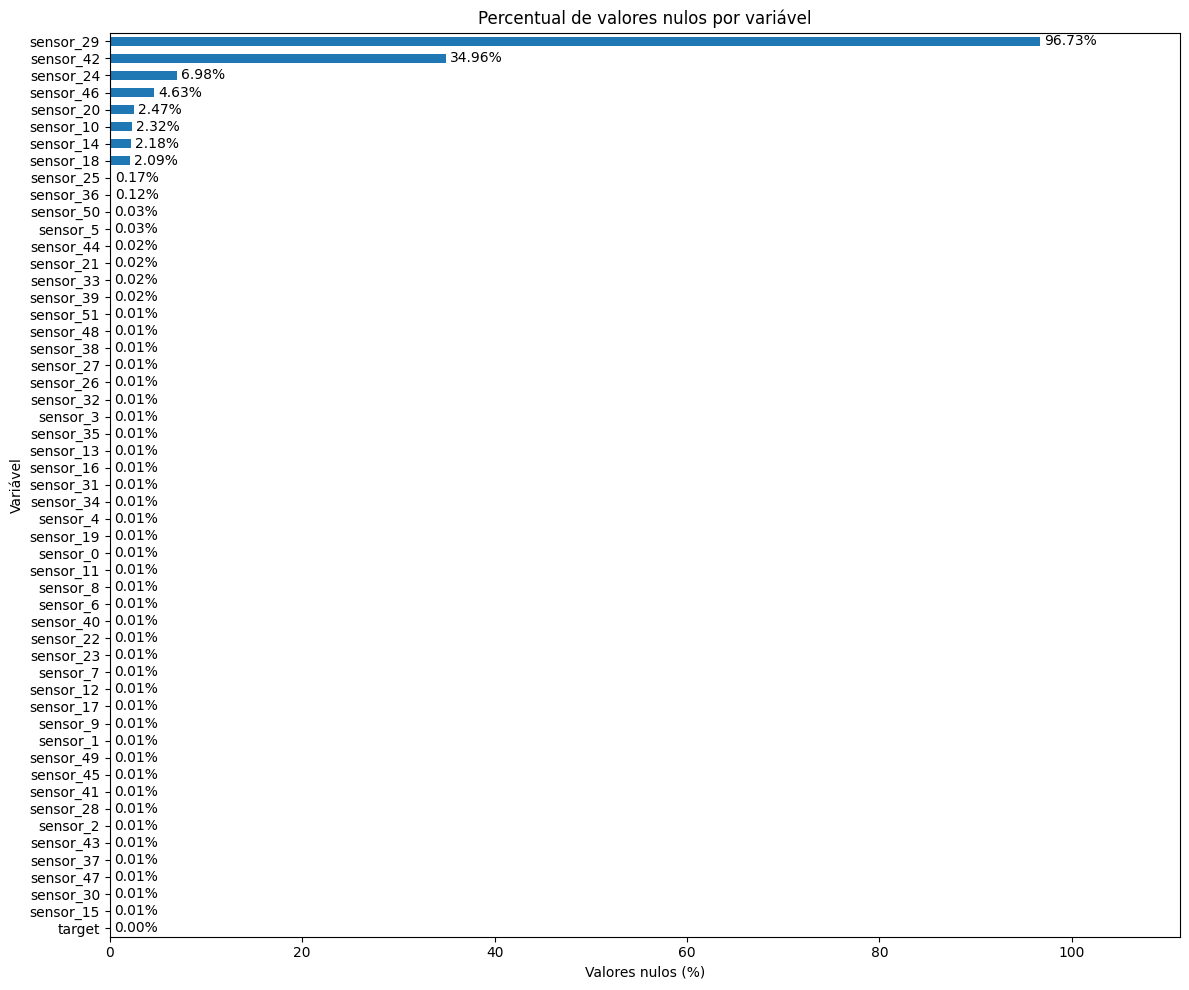

In [12]:
percentuais = nulos["percentual_nulos"].sort_values()

fig, ax = plt.subplots(figsize=(12, 10))

percentuais.plot.barh(ax=ax)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{valor:.2f}%" for valor in percentuais],
        padding=3
    )

ax.set_xlabel("Valores nulos (%)")
ax.set_ylabel("Variável")
ax.set_title("Percentual de valores nulos por variável")

ax.set_xlim(0, percentuais.max() * 1.15)

plt.tight_layout()
plt.show()

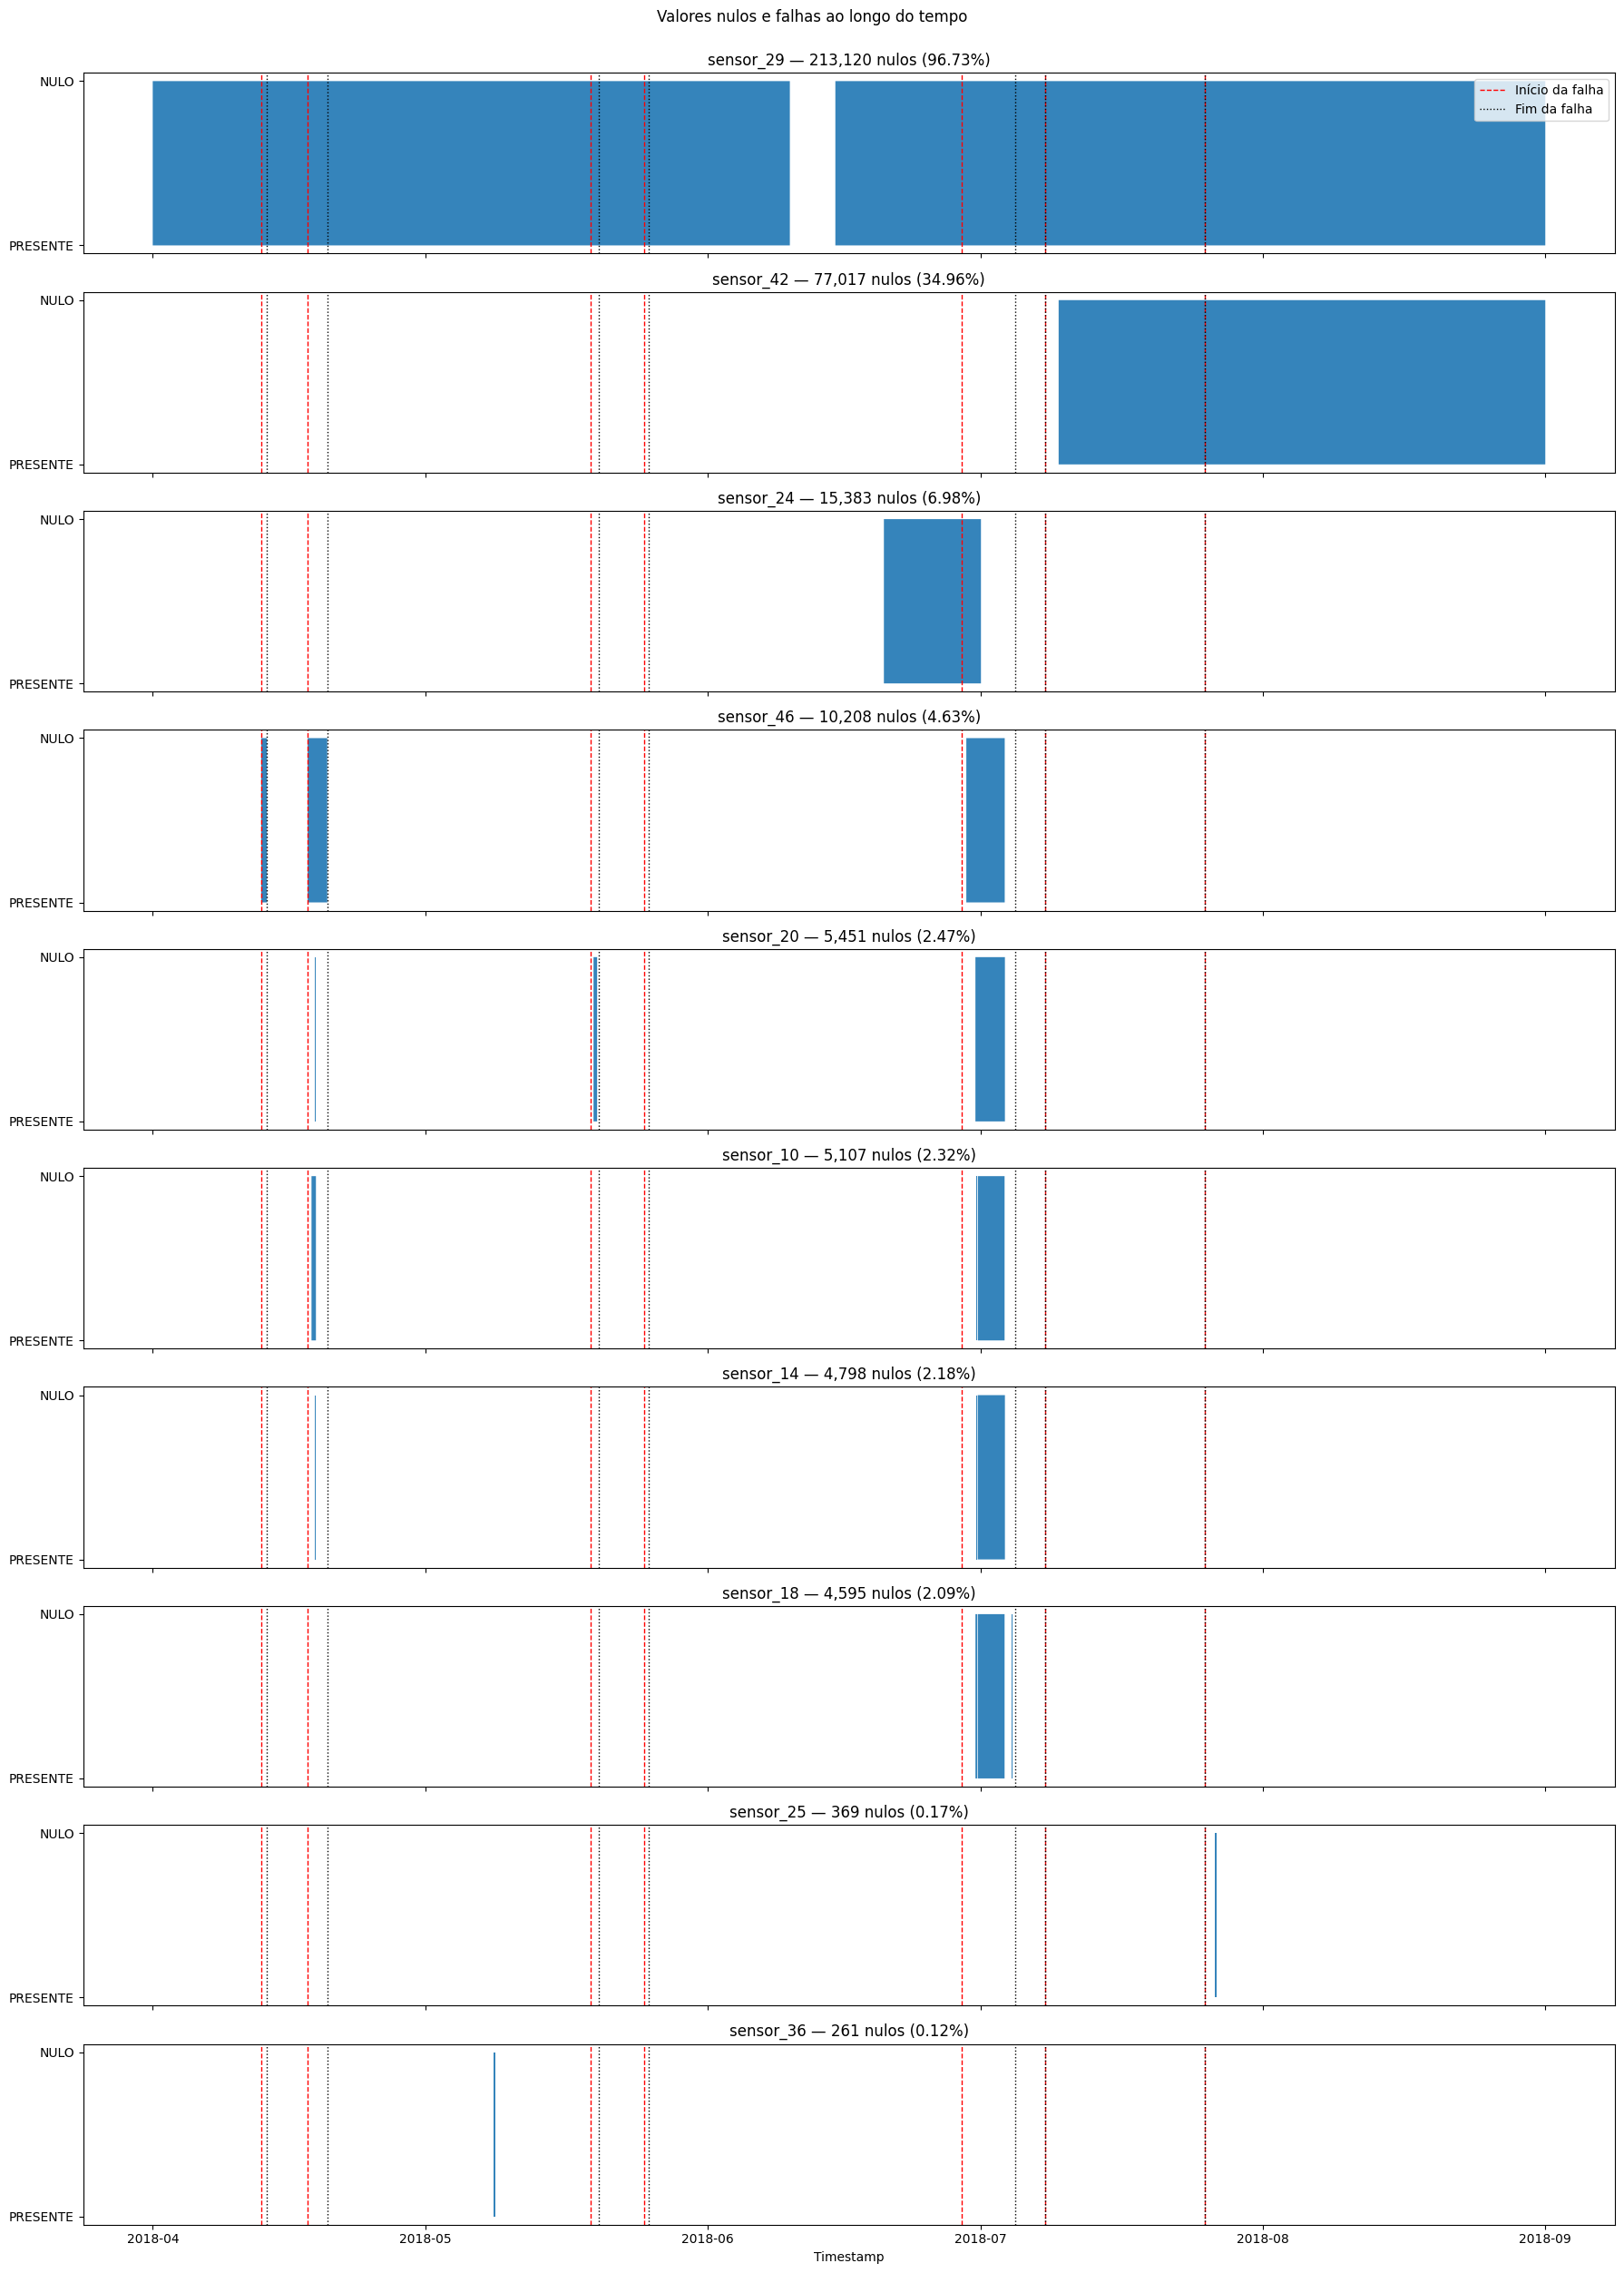

In [13]:
plotar_nulos_no_tempo(
    eda_df,
    variaveis=nulos.index[:10].tolist()
)

## Analisando outliers

## Analisando períodos antes e depois da falha

In [14]:
def plotar_janela_falha(df, numero_falha, minutos=60):
    sensor_cols = df.filter(regex=r"^sensor_\d+$").columns
    target = df["target"]

    inicios = df.index[target.eq(1) & target.shift(fill_value=0).eq(0)]
    finais = df.index[target.eq(1) & target.shift(-1, fill_value=0).eq(0)]

    falhas = pd.DataFrame({
        "inicio": inicios,
        "fim": finais
    }).reset_index(drop=True)

    inicio = falhas.loc[numero_falha, "inicio"]
    fim = falhas.loc[numero_falha, "fim"]

    pre = df.loc[inicio - pd.Timedelta(minutes=minutos):inicio, sensor_cols]

    pos = df.loc[fim:fim + pd.Timedelta(minutes=minutos), sensor_cols]

    media = df[sensor_cols].mean()
    desvio = df[sensor_cols].std()

    pre = (pre - media) / desvio
    pos = (pos - media) / desvio

    fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharey=True)

    axes[0].plot(pre.index, pre, linewidth=0.8, alpha=0.6)
    axes[0].axvline(inicio, color="red", linestyle="--")
    axes[0].set_title(f"60 minutos antes da falha {numero_falha}")
    axes[0].set_ylabel("Valor padronizado")

    axes[1].plot(pos.index, pos, linewidth=0.8, alpha=0.6)
    axes[1].axvline(fim, color="black", linestyle="--")
    axes[1].set_title(f"60 minutos após a falha {numero_falha}")
    axes[1].set_xlabel("Timestamp")
    axes[1].set_ylabel("Valor padronizado")

    plt.tight_layout()
    plt.show()

    print(f"Início da falha: {inicio}")
    print(f"Fim da falha: {fim}")

Vamos levantar a nossa primeira hipótese acerca dos dados:

- **HIPÓTESE 1**: A distribuição dos dados antes e depois da falha é diferente.

> Se as distribuições possuírem diferença estatística para um sensor específico, então, este sensor explica, em um certo nível, aquela falha na máquina.

Para isso, iremos definir nossas hipóteses $H_0$ e $H_1$, e iremos utilizar o teste de Wilcoxon para comparar as duas distribuições.

- $H_0$ (hipótese nula): a distribuição dos valores do sensor nos períodos pré-falha e pós-falha é a mesma.
- $H_1$ (hipótese alternativa): a distribuição dos valores do sensor nos períodos pré-falha e pós-falha é diferente.

In [15]:
def testar_pre_pos_falhas(
    df,
    minutos_pre=60,
    minutos_pos=60,
    alpha=0.05
):
    dados = df.sort_index()
    sensor_cols = dados.filter(regex=r"^sensor_\d+$").columns.tolist()
    target = dados["target"]

    inicios = dados.index[
        target.eq(1) & target.shift(fill_value=0).eq(0)
    ]

    finais = dados.index[
        target.eq(1) & target.shift(-1, fill_value=0).eq(0)
    ]

    resultados = pd.DataFrame(index=sensor_cols)
    significativos = {sensor: [] for sensor in sensor_cols}

    for numero, (inicio, fim) in enumerate(zip(inicios, finais), start=1):
        nome_falha = f"falha_{numero}"

        pre = dados.loc[
            (dados.index >= inicio - pd.Timedelta(minutes=minutos_pre)) &
            (dados.index < inicio),
            sensor_cols
        ]

        pos = dados.loc[
            (dados.index > fim) &
            (dados.index <= fim + pd.Timedelta(minutes=minutos_pos)),
            sensor_cols
        ]

        for sensor in sensor_cols:
            # Inverte o pré para parear pela distância até a falha
            antes = pre[sensor].iloc[::-1].reset_index(drop=True)
            depois = pos[sensor].reset_index(drop=True)

            n = min(len(antes), len(depois))

            pares = pd.concat(
                [antes.iloc[:n], depois.iloc[:n]],
                axis=1,
                keys=["pre", "pos"]
            ).dropna()

            if len(pares) == 0:
                p_value = np.nan

            elif np.allclose(pares["pre"], pares["pos"]):
                p_value = 1.0

            else:
                p_value = wilcoxon(
                    pares["pre"],
                    pares["pos"],
                    alternative="two-sided"
                ).pvalue

            resultados.loc[sensor, nome_falha] = p_value

            if pd.notna(p_value) and p_value < alpha:
                significativos[sensor].append(nome_falha)

    resultados = resultados.astype(float).round(4)

    display(
        resultados.style
        .format("{:.4f}", na_rep="-")
        .map(
            lambda valor: (
                "background-color: lightcoral; font-weight: bold"
                if pd.notna(valor) and valor < alpha
                else ""
            )
        )
    )

    return resultados, significativos

In [17]:
p_values_df, falhas_significativas = testar_pre_pos_falhas(
    eda_df,
    minutos_pre=60,
    minutos_pos=60
)

,falha_1,falha_2,falha_3,falha_4,falha_5,falha_6,falha_7
sensor_0,0.0000,0.0000,0.0000,0.0000,0.0000,0.1294,0.0000
sensor_1,0.0000,0.2759,0.0000,0.0001,0.2727,0.2028,0.0000
sensor_2,0.2189,0.8540,0.0161,0.0192,0.0000,0.5315,0.2189
sensor_3,0.0000,0.0000,0.0000,0.0000,0.3460,0.0111,0.0000
sensor_4,0.0000,0.0000,0.0000,0.0000,0.4616,0.0000,0.0000
sensor_5,0.1409,0.6115,0.0452,0.1053,0.0000,0.1597,0.4483
sensor_6,0.8195,0.8540,0.9238,0.2632,0.2825,0.0798,0.9179
sensor_7,0.2925,0.0502,0.3097,0.0029,0.4055,0.4706,0.9941
sensor_8,0.6115,0.3770,0.0947,0.2993,0.0000,0.0748,0.5910
sensor_9,0.0469,0.0511,0.4483,0.1186,0.4097,0.0216,0.5219


In [19]:
def _ajuste_bh(p_values):
    p_values = pd.Series(p_values, dtype=float)
    validos = p_values.dropna()

    ordem = np.argsort(validos.values)
    ordenados = validos.values[ordem]
    m = len(ordenados)

    ajustados = ordenados * m / np.arange(1, m + 1)
    ajustados = np.minimum.accumulate(ajustados[::-1])[::-1]
    ajustados = np.clip(ajustados, 0, 1)

    resultado = pd.Series(np.nan, index=p_values.index)
    resultado.loc[validos.index[ordem]] = ajustados

    return resultado


def _efeito_bisserial(diferencas):
    diferencas = np.asarray(diferencas)
    diferencas = diferencas[diferencas != 0]

    if len(diferencas) == 0:
        return 0.0

    postos = rankdata(np.abs(diferencas))

    positivos = postos[diferencas > 0].sum()
    negativos = postos[diferencas < 0].sum()

    return (positivos - negativos) / (positivos + negativos)


def rankear_sensores_por_falha(
    df,
    minutos_pre=60,
    minutos_pos=60,
    alpha=0.05,
    top_n=10
):
    dados = df.sort_index()
    sensores = dados.filter(regex=r"^sensor_\d+$").columns.tolist()
    target = dados["target"]

    inicios = dados.index[
        target.eq(1) & target.shift(fill_value=0).eq(0)
    ]

    finais = dados.index[
        target.eq(1) & target.shift(-1, fill_value=0).eq(0)
    ]

    resultados = []

    for numero, (inicio, fim) in enumerate(zip(inicios, finais), start=1):
        falha = f"falha_{numero}"

        pre = dados.loc[
            (dados.index >= inicio - pd.Timedelta(minutes=minutos_pre)) &
            (dados.index < inicio),
            sensores
        ]

        pos = dados.loc[
            (dados.index > fim) &
            (dados.index <= fim + pd.Timedelta(minutes=minutos_pos)),
            sensores
        ]

        for sensor in sensores:
            antes = pre[sensor].iloc[::-1].reset_index(drop=True)
            depois = pos[sensor].reset_index(drop=True)

            n = min(len(antes), len(depois))

            pares = pd.concat(
                [antes.iloc[:n], depois.iloc[:n]],
                axis=1,
                keys=["pre", "pos"]
            ).dropna()

            if len(pares) < 2:
                p_value = np.nan
                efeito = np.nan
                delta = np.nan
            else:
                diferencas = pares["pos"] - pares["pre"]
                delta = diferencas.median()
                efeito = _efeito_bisserial(diferencas)

                p_value = (
                    1.0
                    if np.allclose(diferencas, 0)
                    else wilcoxon(
                        pares["pre"],
                        pares["pos"],
                        alternative="two-sided"
                    ).pvalue
                )

            resultados.append({
                "falha": falha,
                "sensor": sensor,
                "p_value": p_value,
                "efeito": efeito,
                "delta_mediana": delta
            })

    ranking = pd.DataFrame(resultados)

    ranking["p_ajustado"] = (
        ranking.groupby("falha")["p_value"]
        .transform(_ajuste_bh)
    )

    ranking["significativo"] = ranking["p_ajustado"] < alpha

    ranking["score"] = (
        ranking["efeito"].abs()
        * -np.log10(ranking["p_ajustado"].clip(lower=1e-300))
    )

    ranking["direcao"] = np.select(
        [
            ranking["delta_mediana"] > 0,
            ranking["delta_mediana"] < 0
        ],
        ["aumentou", "diminuiu"],
        default="sem mudança"
    )

    ranking["rank"] = (
        ranking.groupby("falha")["score"]
        .rank(ascending=False, method="min")
    )

    ranking = ranking.sort_values(
        ["falha", "significativo", "score"],
        ascending=[True, False, False]
    )

    melhores_por_falha = (
        ranking[ranking["significativo"]]
        .groupby("falha", group_keys=False)
        .head(top_n)
        .groupby("falha")["sensor"]
        .apply(list)
        .to_dict()
    )

    resumo = (
        ranking[ranking["significativo"]]
        .groupby("falha", group_keys=False)
        .head(top_n)
    )

    display(
        resumo.style
        .format({
            "p_value": "{:.4f}",
            "p_ajustado": "{:.4f}",
            "efeito": "{:.3f}",
            "delta_mediana": "{:.3f}",
            "score": "{:.3f}",
            "rank": "{:.0f}"
        })
        .background_gradient(subset=["score"])
    )

    return ranking, melhores_por_falha

In [20]:
ranking_df, melhores_sensores = rankear_sensores_por_falha(
    eda_df,
    minutos_pre=60,
    minutos_pos=60,
    top_n=10
)

,falha,sensor,p_value,efeito,delta_mediana,p_ajustado,significativo,score,direcao,rank
26,falha_1,sensor_26,0.0000,1.000,652.107,0.0000,True,9.551,aumentou,1
42,falha_1,sensor_42,0.0000,-1.000,-230.610,0.0000,True,9.551,diminuiu,1
4,falha_1,sensor_4,0.0000,-0.999,-6.850,0.0000,True,9.540,diminuiu,3
1,falha_1,sensor_1,0.0000,-0.993,-197.366,0.0000,True,9.488,diminuiu,4
16,falha_1,sensor_16,0.0000,-0.965,-35.239,0.0000,True,8.770,diminuiu,5
3,falha_1,sensor_3,0.0000,-0.827,-38.644,0.0000,True,5.519,diminuiu,6
34,falha_1,sensor_34,0.0000,-0.793,-47.803,0.0000,True,4.904,diminuiu,7
24,falha_1,sensor_24,0.0000,-0.785,-150.737,0.0000,True,4.785,diminuiu,8
35,falha_1,sensor_35,0.0000,-0.667,-68.143,0.0000,True,2.941,diminuiu,9
0,falha_1,sensor_0,0.0000,0.664,6.790,0.0000,True,2.931,aumentou,10


In [21]:
for falha, sensores in melhores_sensores.items():
    print(f"{falha}: {', '.join(sensores)}")

falha_1: sensor_26, sensor_42, sensor_4, sensor_1, sensor_16, sensor_3, sensor_34, sensor_24, sensor_35, sensor_0
falha_2: sensor_4, sensor_16, sensor_42, sensor_0, sensor_3, sensor_34, sensor_37, sensor_46, sensor_26, sensor_13
falha_3: sensor_4, sensor_42, sensor_26, sensor_35, sensor_28, sensor_16, sensor_3, sensor_46, sensor_24, sensor_0
falha_4: sensor_4, sensor_42, sensor_0, sensor_16, sensor_12, sensor_37, sensor_24, sensor_3, sensor_46, sensor_49
falha_5: sensor_5, sensor_23, sensor_51, sensor_27, sensor_47, sensor_0, sensor_40, sensor_36, sensor_21, sensor_8
falha_6: sensor_4, sensor_16, sensor_37, sensor_12, sensor_34, sensor_13, sensor_46, sensor_45
falha_7: sensor_4, sensor_16, sensor_51, sensor_1, sensor_34, sensor_3, sensor_13, sensor_24, sensor_41, sensor_0


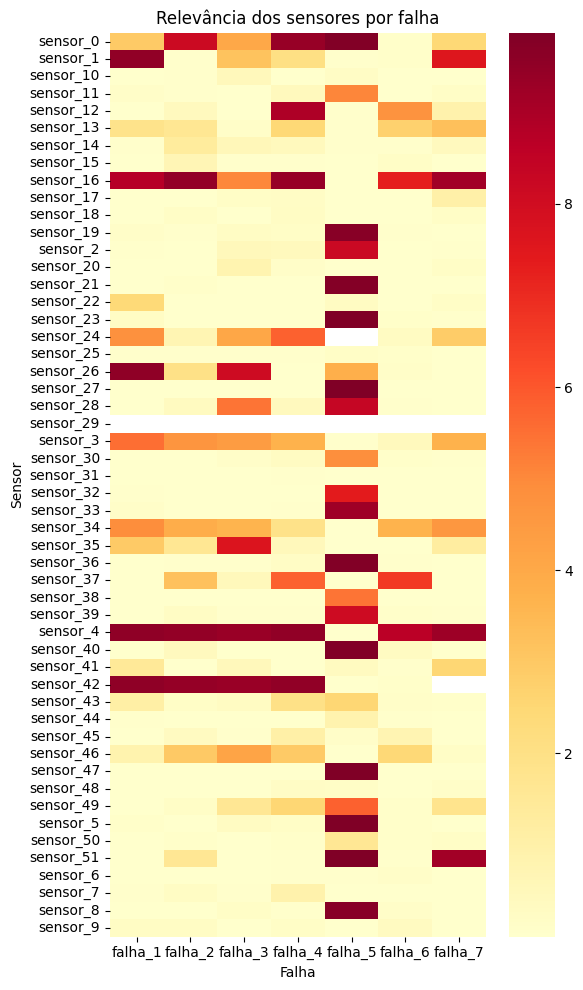

In [28]:
matriz_score = ranking_df.pivot(
    index="sensor",
    columns="falha",
    values="score"
)

fig, ax = plt.subplots(figsize=(6, 10))

sns.heatmap(
    matriz_score,
    cmap="YlOrRd",
    ax=ax
)

ax.set_title("Relevância dos sensores por falha")
ax.set_xlabel("Falha")
ax.set_ylabel("Sensor")

plt.tight_layout()
plt.show()

Também podemos analisar as distribuições visualmente para verificar se os testes estatísticos fazem sentido.

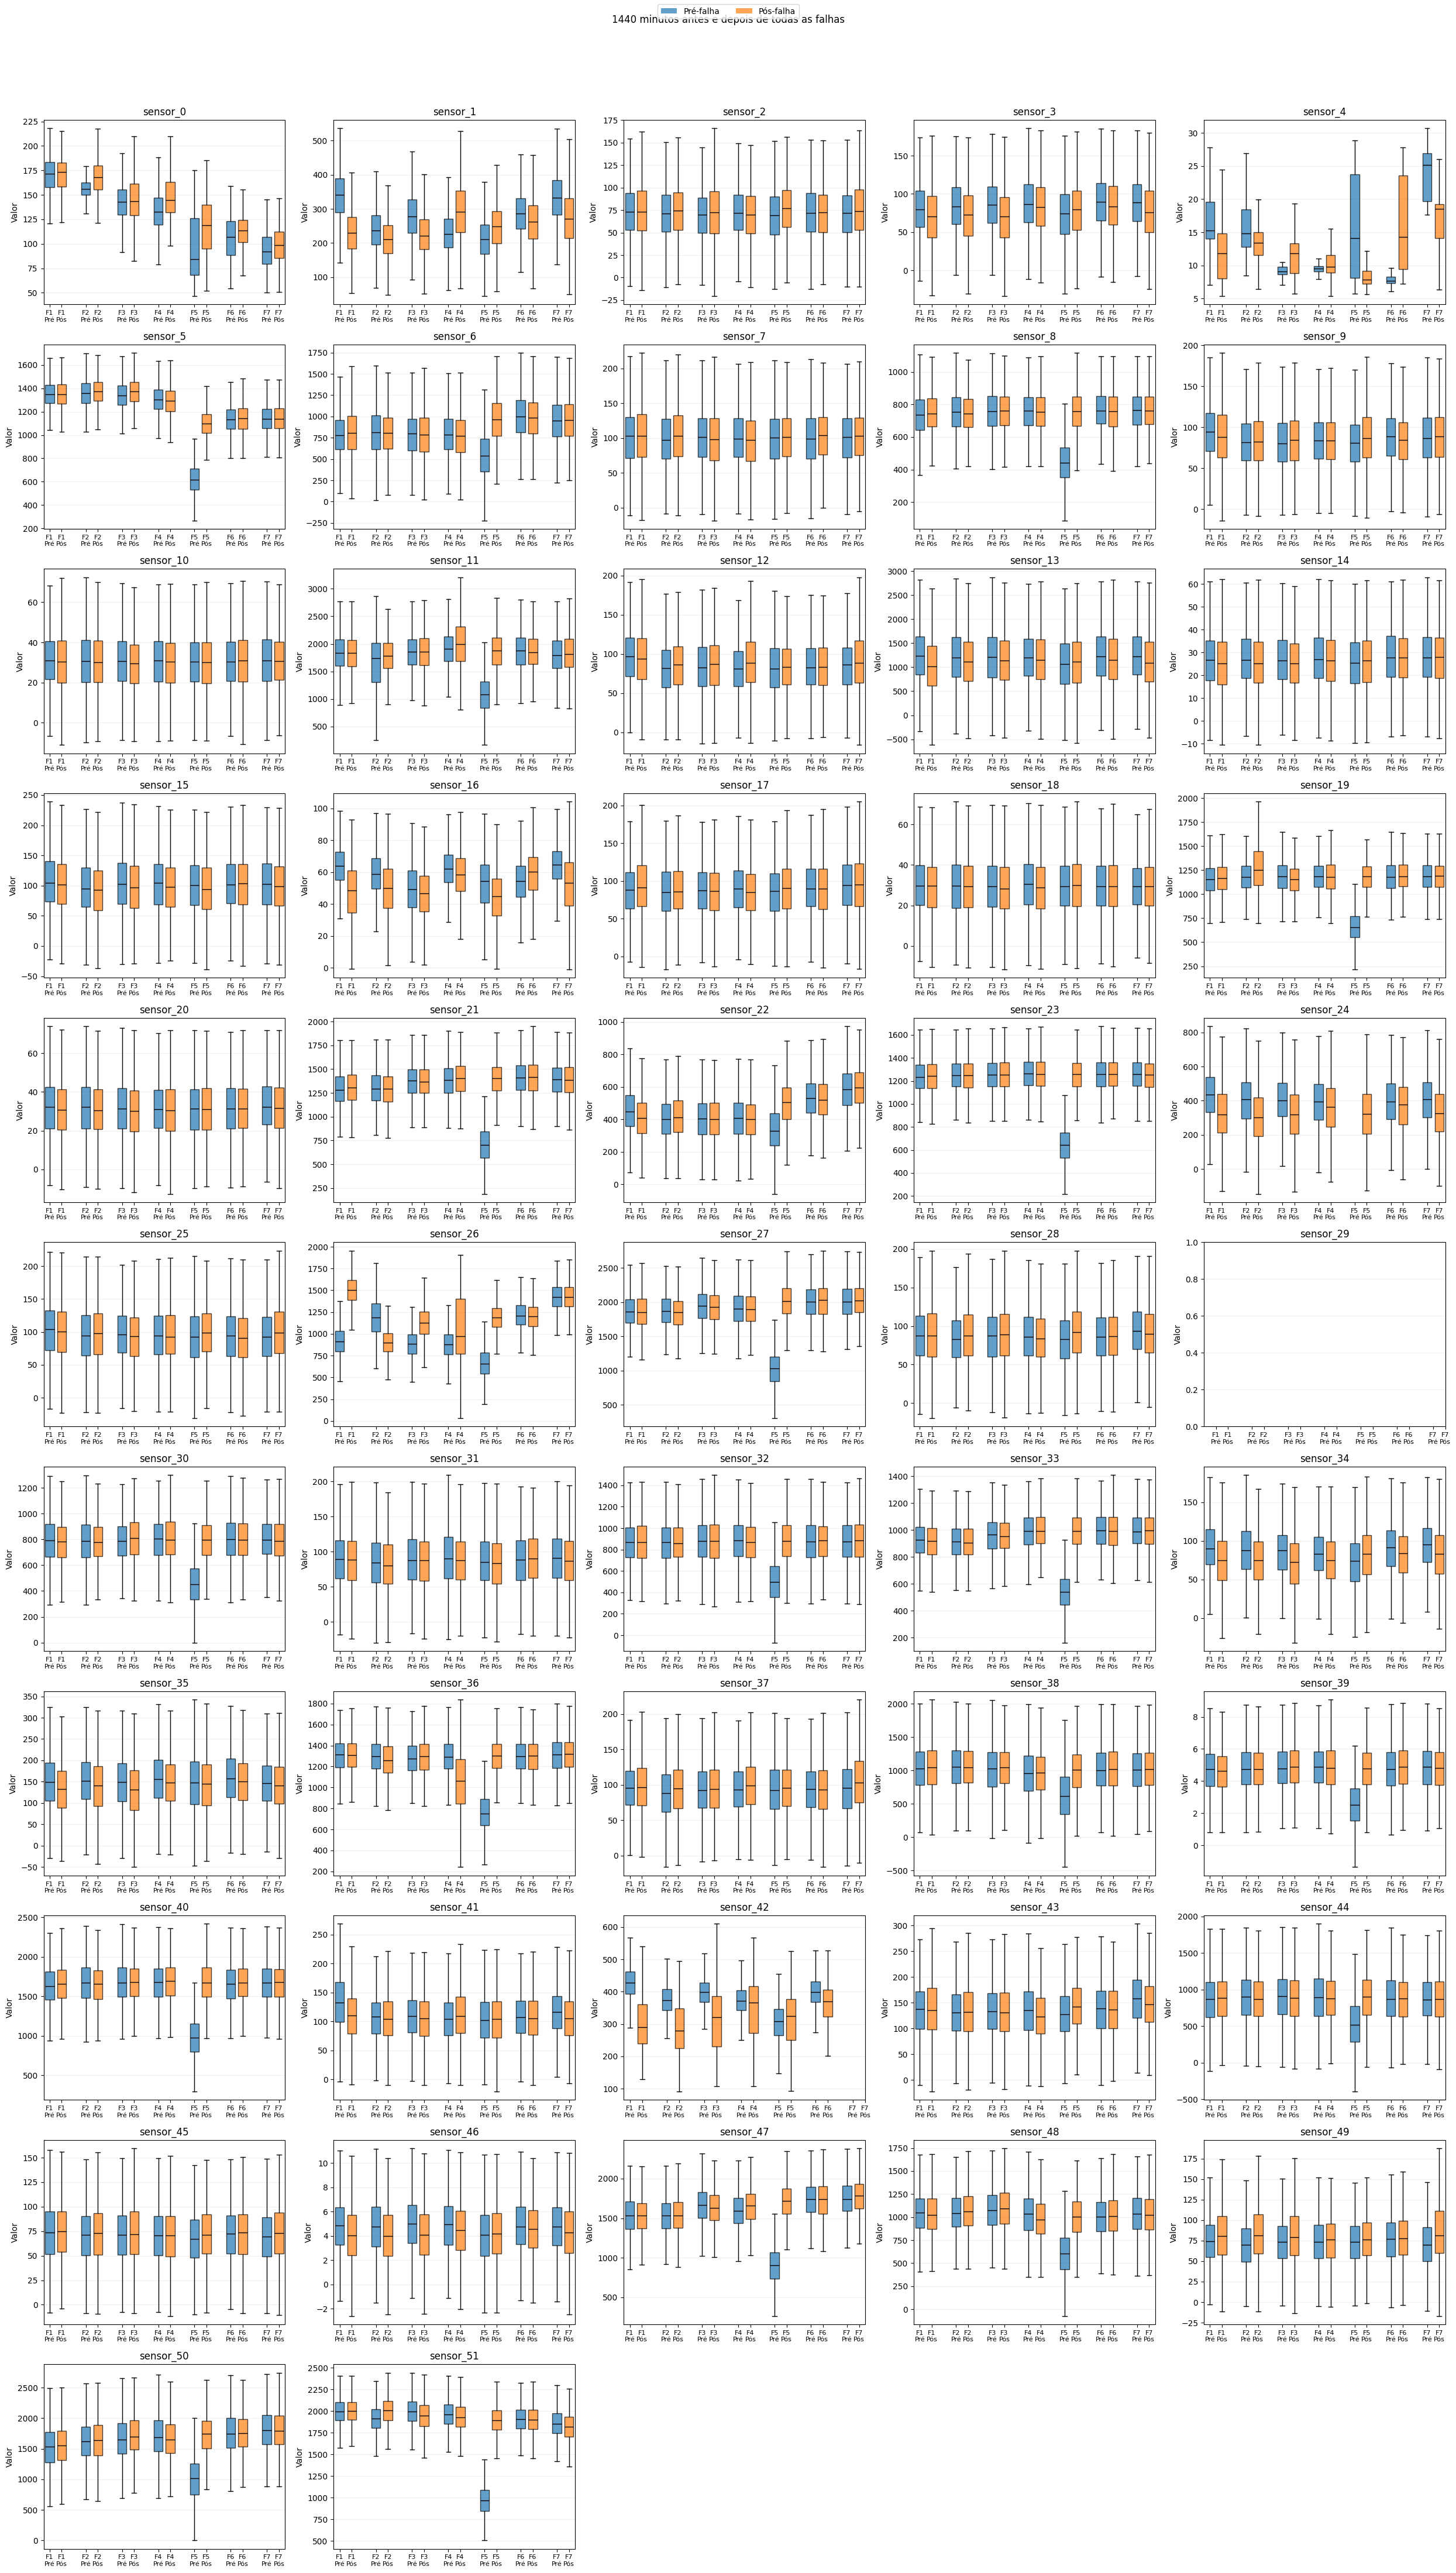

In [59]:
plotar_boxplots_todas_falhas(
    eda_df,
    minutos=24 * 60
)

## Analisando sazonalidades